 Dataset Distribution (Class Balance)

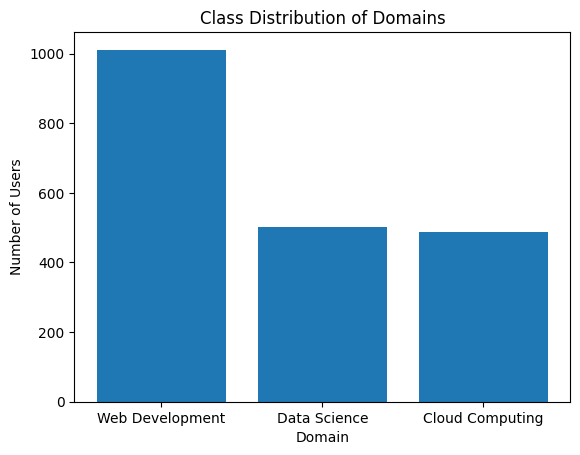

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Step 1: Load the dataset
# Make sure your dataset file is in the correct path
df = pd.read_csv("balanced_domain_recommendation_data.csv")

# Step 2: Encode the 'Domain' target variable
label_encoder = LabelEncoder()
df["Domain"] = label_encoder.fit_transform(df["Domain"])

# Step 3: Create a bar chart for class distribution
domain_counts = df['Domain'].value_counts()
domain_labels = label_encoder.inverse_transform(domain_counts.index)

# Plot the distribution
plt.bar(domain_labels, domain_counts)
plt.xlabel("Domain")
plt.ylabel("Number of Users")
plt.title("Class Distribution of Domains")
plt.show()


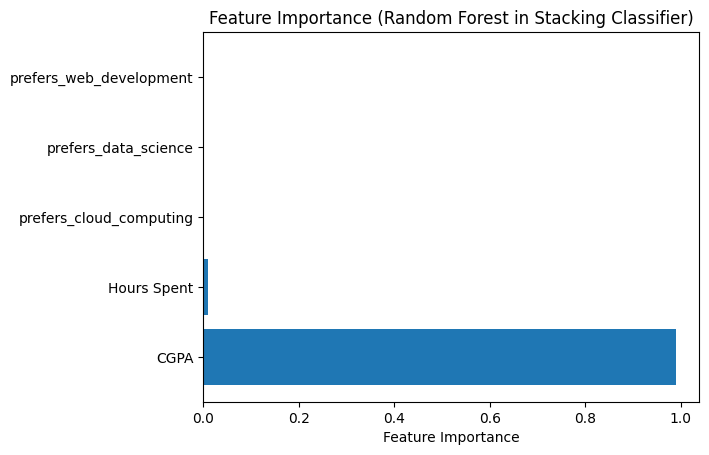

In [4]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Step 1: Load the dataset
df = pd.read_csv("balanced_domain_recommendation_data.csv")

# Encode the 'Domain' target variable
label_encoder = LabelEncoder()
df["Domain"] = label_encoder.fit_transform(df["Domain"])

# Add user preferences as binary features
df["prefers_cloud_computing"] = np.where(df["Domain"] == "Cloud Computing", 1, 0)
df["prefers_data_science"] = np.where(df["Domain"] == "Data Science", 1, 0)
df["prefers_web_development"] = np.where(df["Domain"] == "Web Development", 1, 0)

# Define features (X) and target (y)
X = df[["CGPA", "Hours Spent", "prefers_cloud_computing", "prefers_data_science", "prefers_web_development"]]  # Features
y = df["Domain"]  # Target variable: Domain

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Create base models for stacking
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)),
    ('xgb', xgb.XGBClassifier(n_estimators=1000, max_depth=10, learning_rate=0.01, objective="multi:softmax", num_class=len(label_encoder.classes_), random_state=42)),
    ('svc', LogisticRegression(random_state=42))
]

# Step 3: Meta-model (Logistic Regression)
meta_model = LogisticRegression()

# Step 4: Create the Stacking Classifier
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model)

# Step 5: Train the Stacking Classifier
stacking_clf.fit(X_train, y_train)

# Step 6: Access the feature importance of RandomForest
importances = stacking_clf.named_estimators_['rf'].feature_importances_
features = ["CGPA", "Hours Spent", "prefers_cloud_computing", "prefers_data_science", "prefers_web_development"]

# Visualize the feature importance
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importance (Random Forest in Stacking Classifier)")
plt.show()


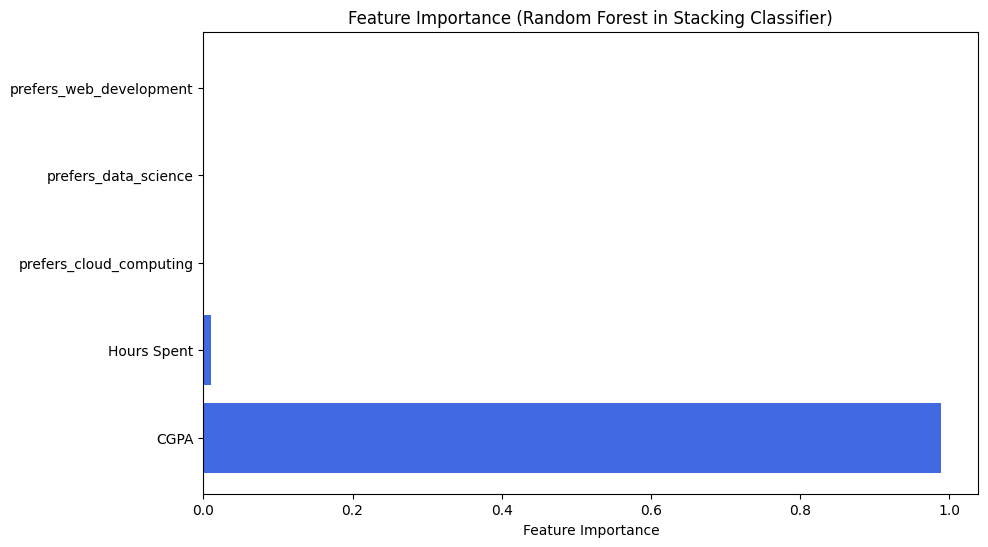

In [5]:
import matplotlib.pyplot as plt

# Assuming stacking_clf is the trained stacking classifier and 'rf' is Random Forest
importances = stacking_clf.named_estimators_['rf'].feature_importances_
features = ["CGPA", "Hours Spent", "prefers_cloud_computing", "prefers_data_science", "prefers_web_development"]

# Visualize the feature importance
plt.figure(figsize=(10, 6))
plt.barh(features, importances, color='royalblue')
plt.xlabel("Feature Importance")
plt.title("Feature Importance (Random Forest in Stacking Classifier)")
plt.show()


CONFUSION MATRIX

Model Performance Comparison (Bar Chart)

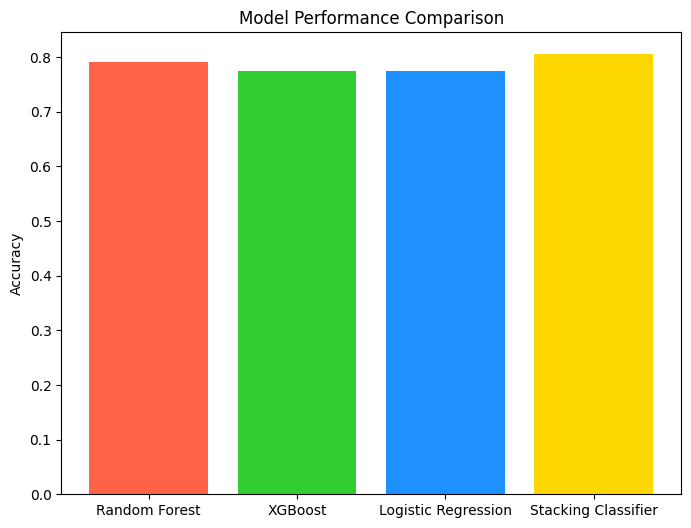

In [12]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Step 1: Load the dataset and preprocess it
df = pd.read_csv("balanced_domain_recommendation_data.csv")

# Encode the 'Domain' target variable
label_encoder = LabelEncoder()
df["Domain"] = label_encoder.fit_transform(df["Domain"])

# Add user preferences as binary features
df["prefers_cloud_computing"] = np.where(df["Domain"] == "Cloud Computing", 1, 0)
df["prefers_data_science"] = np.where(df["Domain"] == "Data Science", 1, 0)
df["prefers_web_development"] = np.where(df["Domain"] == "Web Development", 1, 0)

# Define features (X) and target (y)
X = df[["CGPA", "Hours Spent", "prefers_cloud_computing", "prefers_data_science", "prefers_web_development"]]  # Features
y = df["Domain"]  # Target variable: Domain

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Create base models for stacking
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
xgb_model = xgb.XGBClassifier(n_estimators=1000, max_depth=10, learning_rate=0.01, objective="multi:softmax", num_class=len(label_encoder.classes_), random_state=42)
lr = LogisticRegression(random_state=42)

# Step 3: Train individual models
rf.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
lr.fit(X_train, y_train)

# Step 4: Calculate accuracy for individual models
rf_accuracy = accuracy_score(y_test, rf.predict(X_test))
xgb_accuracy = accuracy_score(y_test, xgb_model.predict(X_test))
lr_accuracy = accuracy_score(y_test, lr.predict(X_test))

# Step 5: Train the Stacking Classifier
stacking_clf.fit(X_train, y_train)

# Step 6: Calculate accuracy for the Stacking Classifier
accuracy = accuracy_score(y_test, stacking_clf.predict(X_test))

# Step 7: Plot Model Performance Comparison
models = ['Random Forest', 'XGBoost', 'Logistic Regression', 'Stacking Classifier']
accuracies = [rf_accuracy, xgb_accuracy, lr_accuracy, accuracy]  # List of model accuracies

# Plot the performance comparison
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['#FF6347', '#32CD32', '#1E90FF', '#FFD700'])
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.show()


Learning Curve (Model Training Performance Over Time)

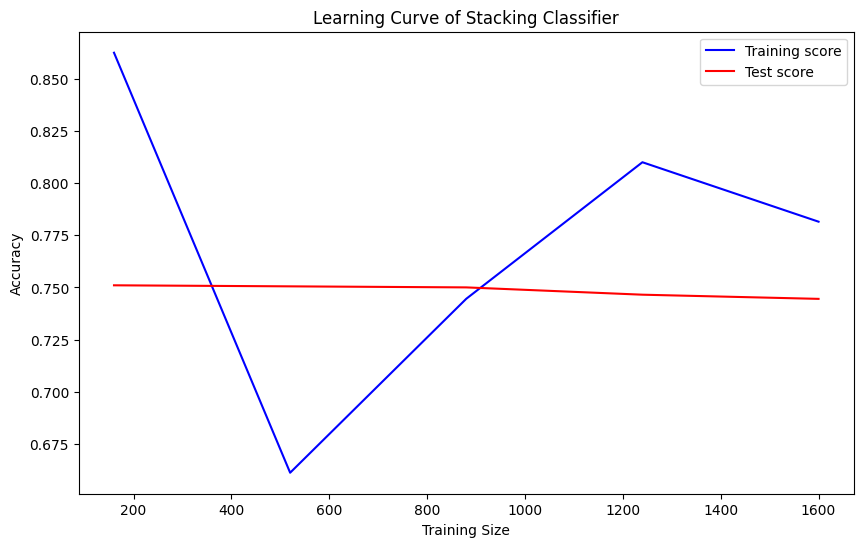

In [8]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(stacking_clf, X, y, cv=5, scoring="accuracy")

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training score", color='blue')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Test score", color='red')
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve of Stacking Classifier")
plt.legend()
plt.show()


User Preference vs Predicted Domain (Scatter Plot)

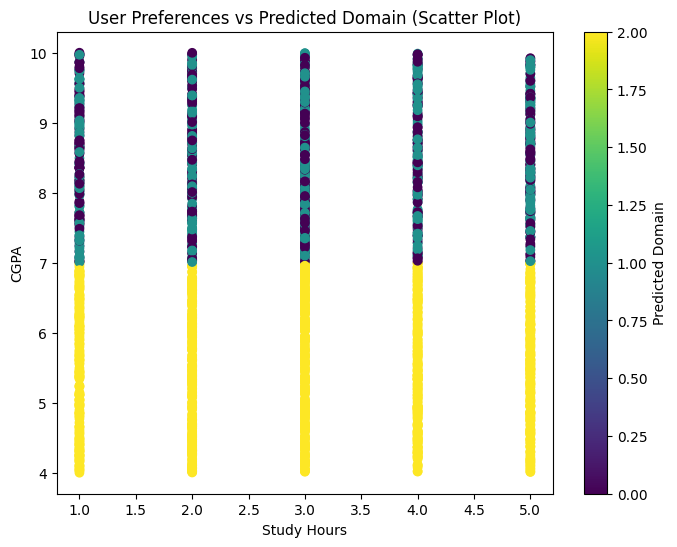

In [9]:
import matplotlib.pyplot as plt

# Assume user preference is in the 'prefers_*' columns
plt.figure(figsize=(8, 6))
plt.scatter(df["Hours Spent"], df["CGPA"], c=df["Domain"], cmap="viridis")
plt.colorbar(label="Predicted Domain")
plt.xlabel("Study Hours")
plt.ylabel("CGPA")
plt.title("User Preferences vs Predicted Domain (Scatter Plot)")
plt.show()


 Correlation Heatmap Between Features and Domain

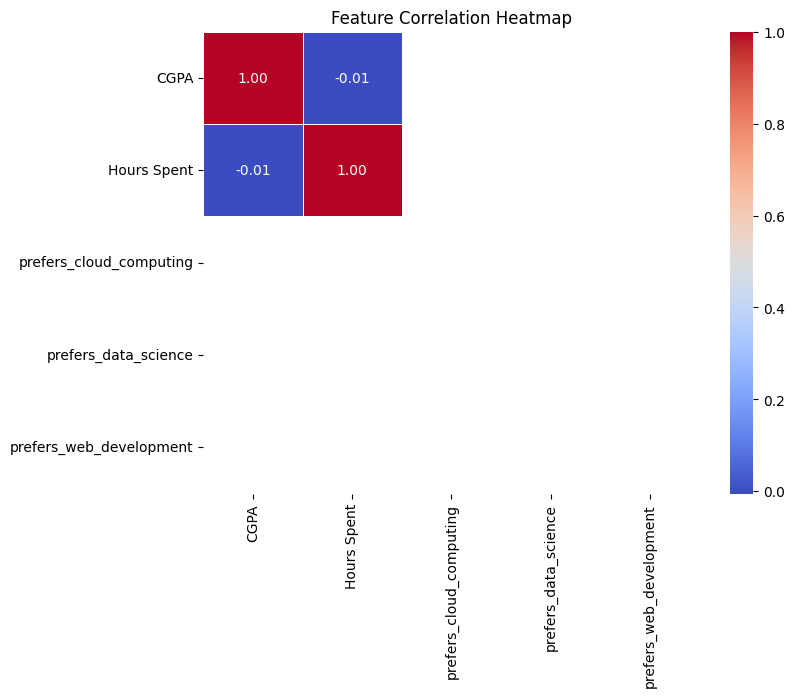

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap for selected features and target variable (Domain)
corr_matrix = df[["CGPA", "Hours Spent", "prefers_cloud_computing", "prefers_data_science", "prefers_web_development"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


Code for Label Distribution Pie Chart:

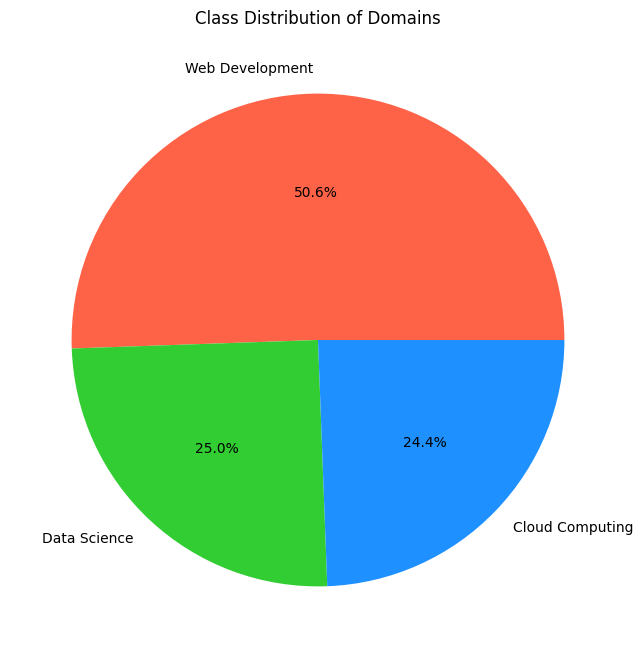

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Step 1: Load the dataset
df = pd.read_csv("balanced_domain_recommendation_data.csv")

# Encode the 'Domain' target variable
label_encoder = LabelEncoder()
df["Domain"] = label_encoder.fit_transform(df["Domain"])

# Step 2: Create a pie chart for class distribution
domain_counts = df['Domain'].value_counts()
domain_labels = label_encoder.inverse_transform(domain_counts.index)

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(domain_counts, labels=domain_labels, autopct='%1.1f%%', colors=['#FF6347', '#32CD32', '#1E90FF'])
plt.title("Class Distribution of Domains")
plt.show()
